In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [2]:
image_path="../output_videos/cropped_image.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

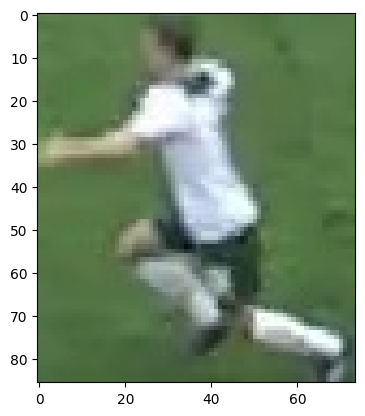

In [5]:
plt.imshow(image)
plt.show()


# take the top half of the image

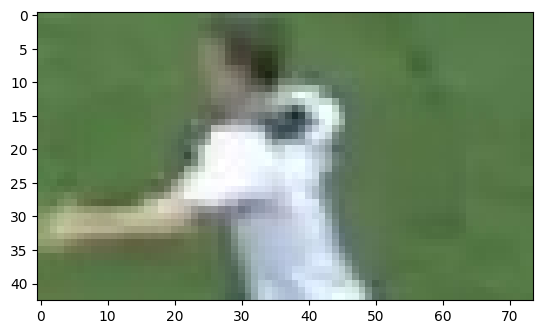

In [ ]:
top_half_image= image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()


# Cluster the image into two clusters

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


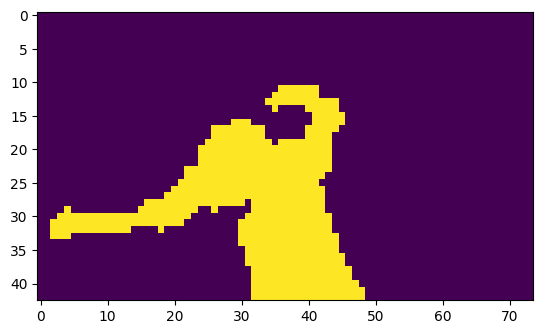

In [10]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering with 2 cluster
kmeans=KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# Get the cluster labels
labels=kmeans.labels_

#reshape  the labels into the original image shape
clustered_image=labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()



In [11]:
corner_clusters=clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]
non_player_cluster=max(set(corner_clusters), key=corner_clusters.count)
print("Non player cluster: ", non_player_cluster)

Non player cluster:  0


In [12]:
player_clustor = 1-non_player_cluster
print("Player cluster: ", player_clustor)


Player cluster:  1


In [13]:
kmeans.cluster_centers_[player_clustor]

array([198.9442446 , 208.93165468, 212.1294964 ])